In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd 
import tensorflow as tf
from tensorflow import keras

Neural networks are built of layers of neurons. The first layer is built of input neurons along with a bias term which always gives 1. The input neurons pass on the information to the next layer. Each connection b/w  neurons of one layer to another have weights associated with them. Each neuron of a layer will have a weight vector of their own, This vector contains connection weights of each neuron in the prev layer. Each layer also has a bias term of their own, except for the output layer.

Each neuron of the hidden layers will have an activation function associated with it, preferrably non-linear inorder to get rid of the linear bias of the neurons and their linear connections with weights and inputs. The succeeding neuron will take weighted input of all preceding neurons it's connected to and evaluate it using the activation function. The result of this activation function is then sent to the succeeding layer until the output layer is reached, which then predicts a certain output.

Multilayer perceptrons can have multiple decision boundaries and hence solve the XOR Problem.

Now, MLP(Multi layer preceptrons) learn using Backpropagation. The algorithm goes as follows- <br>
A mini batch of the training set is sent throught the network and the output error is recorded. Intermediate results are stored instead of discarded. Now, we go backwards from the output layer to the input layer while calculating the individual error each connection in the layers made. Then, using the chain rule for derivatives it calculates the magnitude of contribution each connection had to the error(just like gradient descent) and scales the connection weights according to the derivatives. This continues till the no. of epochs is reached or the tolerance is reached.

For Regression tasks, the loss function is typically MSE or MAE/Huber(If outliers are more) <br>
For Classification tasks, the loss fn is usually Cross Entropy, as in the case of Logit and Softmax.


In [2]:
dataset = keras.datasets.fashion_mnist
(xTrain,yTrain), (xTest,yTest) = dataset.load_data()

xVal,xTrain = xTrain[:5000]/255.0, xTrain[5000:]/255
yVal,yTrain = yTrain[:5000], yTrain[5000:]
xTest = xTest/255

labelNames = np.array(["Tshirt/top", "Trousers", "Pullover", "Dress", "Coat", "Sandals", "Shirt", "Sneakers", "Bag", "Ankle Boots"]) # These are indexed according to the dataset.

In [3]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28])) # This is a flatten layer and it reshapes the 28x28 matrix to a vector
model.add(keras.layers.Dense(300,activation="relu")) # dense HL with 300 neurons
model.add(keras.layers.Dense(100,activation="relu")) # dense HL with 100 neurons
model.add(keras.layers.Dense(10,activation="softmax")) # 10 because 10 total outputs, softmax since classes are exclusive

model.summary() # succintly displays the parameters of the model.

c:\Users\yug\Desktop\Projects\AIML - 2\uvenv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
print(model.name,'\n', model.layers[0], '\n',model.layers[1], '\n',model.layers[3].name)

sequential 
 <Flatten name=flatten, built=True> 
 <Dense name=dense, built=True> 
 dense_2


In [5]:
hl1 = model.layers[1]
weights,biases = hl1.get_weights()
weights[0] # randomly initialized connectionn weights to hl2 for first neuron

array([ 0.03092946,  0.03888647,  0.07199641,  0.0092684 ,  0.04124679,
        0.04261601, -0.04722297,  0.0029014 , -0.04912923,  0.05182356,
        0.01120089,  0.04322525,  0.02972777, -0.07005147,  0.06312157,
       -0.04137427, -0.00814843, -0.01138632, -0.01432917,  0.02020712,
       -0.01084562,  0.00496456,  0.0095863 , -0.00864142,  0.06169774,
       -0.01736715, -0.02356068,  0.01761686,  0.00728621,  0.00543071,
       -0.01640799, -0.0527837 , -0.02091071, -0.04506993,  0.0044895 ,
       -0.06021705,  0.00824308, -0.05436124,  0.0656867 , -0.00558382,
       -0.07041769,  0.02250139,  0.00489909, -0.04213897, -0.00180206,
        0.02097927,  0.02401897, -0.01737607,  0.02584522,  0.02525871,
        0.06573805, -0.0728505 ,  0.05069314,  0.0086275 , -0.02562274,
       -0.03828826,  0.02857483, -0.04921419, -0.0692434 ,  0.00079994,
       -0.05338537,  0.06831551,  0.02832372, -0.06309655,  0.0580086 ,
        0.03244293,  0.02169925,  0.02705944,  0.07293938,  0.07

In [6]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

Above, since we have 0-9 values for output encoded in 0-9 numbers, we will use that loss. If we had one-hot encoded values, it wouldn't be sparse anymore and we'd use categorical_entropy. If we were doing binary clf, we'd use sigmoid activation fn instead of softmax and loss would be binary_crossentropy

In [7]:
fitted = model.fit(xTrain,yTrain, epochs=20, validation_data=(xVal,yVal))
# fitted is a History object containing info about individual epochs and the model.

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6812 - loss: 0.9996 - val_accuracy: 0.8316 - val_loss: 0.4976
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8239 - loss: 0.5051 - val_accuracy: 0.8390 - val_loss: 0.4662
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8393 - loss: 0.4554 - val_accuracy: 0.8592 - val_loss: 0.4136
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8521 - loss: 0.4212 - val_accuracy: 0.8494 - val_loss: 0.4200
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8583 - loss: 0.3993 - val_accuracy: 0.8668 - val_loss: 0.3806
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8654 - loss: 0.3823 - val_accuracy: 0.8574 - val_loss: 0.3966
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8699 - loss: 0.3683 - val_accuracy: 0.8476 - val_loss: 0.4062
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8751 - loss: 0.3557 - 

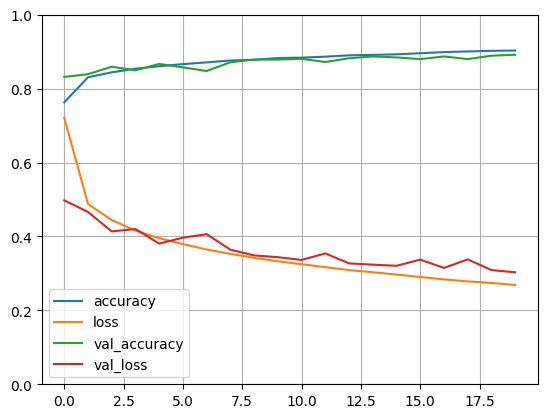

In [8]:
pd.DataFrame(fitted.history).plot()
plt.grid(True)
plt.ylim(0,1)
plt.show() 

#In the beginning, val acc seems less than train acc. This is because val acc is measured once at end of epoch, while train acc is the avg of all acc's for each epoch.
# We should probably call fit() again since the val error seems to keep going down. 

In [9]:
model.evaluate(xTest,yTest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8788 - loss: 0.3389


[0.33652734756469727, 0.8790000081062317]

In [10]:
xNew= xTest[:3]
predProba = model.predict(xNew).round(3)
predClasses = np.argmax(predProba, axis=1)
labelNames[predClasses]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


array(['Ankle Boots', 'Pullover', 'Trousers'], dtype='<U11')

Similarly, we can create a sequential model for regression.

In [11]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()

xTrain,xTest,yTrain,yTest = train_test_split(housing.data, housing.target)
xTrain,xVal,yTrain,yVal = train_test_split(xTrain,yTrain)

In [12]:
scaler = StandardScaler()
xTrain = scaler.fit_transform(xTrain)
xTest = scaler.transform(xTest)
xVal = scaler.transform(xVal)

In [13]:
model = keras.models.Sequential()
model.add(keras.layers.Dense(30,activation="relu", input_shape=xTrain.shape[1:]))
model.add(keras.layers.Dense(1))

model.compile(optimizer="sgd", loss="mean_squared_error")

c:\Users\yug\Desktop\Projects\AIML - 2\uvenv\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
history = model.fit(xTrain,yTrain,epochs=20,validation_data=(xVal,yVal))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2479 - val_loss: 0.5468
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4754 - val_loss: 0.6408
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4189 - val_loss: 0.4915
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3843 - val_loss: 0.4162
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3878 - val_loss: 0.4158
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3813 - val_loss: 0.4520
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3705 - val_loss: 0.4001
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3622 - val_loss: 0.5747
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3671 - val_loss: 0.4073
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3698 - val_loss: 0.5723
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3544 - val_loss: 0.3988
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

WIDE AND DEEP NEURAL NETWORK USING FUNCTIONAL API OF KERAS

In [15]:
xTrain.shape[1]

8

In [16]:
input_ = keras.layers.Input(shape=xTrain.shape[1:]) # [1:] instead of [1] keeps it a tuple object instead of integer
hidden1 = keras.layers.Dense(30,activation="relu")(input_) # the functional (input_) shows that this layer will be connected to input_.
hidden2 = keras.layers.Dense(30,activation="relu")(hidden1)
hidden3 = keras.layers.Dense(30,activation="relu")(hidden2)
concat = keras.layers.Concatenate()([input_,hidden3]) # hidden2 since we want to skip all hidden layers. concat layer will appear after hidden2
output = keras.layers.Dense(1)(concat) # 1 neuron, output layer
model = keras.Model(inputs=[input_],outputs=[output])

Explanation of the code above----

First, we create an input layer with vector shape input. <br>
Then, hidden1 is created and functionally input_ is passed to connect it with input_. Similar with hidden2.<br>
Now, we create a Concatenate layer and use it similarly like to function in order to concat input to after hidden2. <br>
Lastly, we create an output layer and then create the model.

In [17]:
model.compile(loss="mean_squared_error", optimizer="adam")

In [18]:
history2 = model.fit(xTrain,yTrain,epochs=20,validation_data=(xVal,yVal))

Epoch 1/20


c:\Users\yug\Desktop\Projects\AIML - 2\uvenv\lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_15']
Received: inputs=Tensor(shape=(None, 8))
  warnings.warn(msg)


363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.9484 - val_loss: 0.4513
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3804 - val_loss: 0.6558
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3606 - val_loss: 0.7011
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3237 - val_loss: 0.9290
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3473 - val_loss: 1.0297
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3379 - val_loss: 1.3813
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3452 - val_loss: 2.0283
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3310 - val_loss: 0.7186
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3114 - val_loss: 0.3601
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2968 - val_loss: 0.8494
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3034 - val_loss: 0.5049
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.

<h1>USE CASES FOR MULTIPLE OUTPUTS</h1>

The task may need it, such as classifying the main object in a photo involves finding the center of the object(regression) and classifying it.<br>
We may have multiple independent tasks based on a single dataset. Training a single NN is better than training several NNs on the same dataset.<br>

We can also regularize using multiple outputs. We may want to add some auxillary outputs in a NN architecture to ensure that the underlying low level part of the network learns something useful on its own without relying on the rest of the network. It helps gradients pass down onto the low level neurons and improves the low level features.

<h1>SUBCLASSING API</h1>